# Customer Churn Prediction

**Industry:** Telecom  
**Problem Type:** Binary Classification  
**Business Goal:** Identify customers likely to cancel their subscription so the retention team can intervene proactively.

---

## Notebook Flow
1. Dataset Generation
2. Exploratory Data Analysis (minimal)
3. Feature Engineering
4. Model Development (Logistic Regression / Decision Tree / Random Forest / XGBoost)
5. Model Comparison & Interpretation

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

# Add parent to path so we can import src/
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

SEED = 42
plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='whitegrid', palette='muted')
print('Libraries loaded.')

Libraries loaded.


---
## 1. Dataset Generation

We generate 7,000 synthetic telecom customer records.  
Churn labels are produced by a logistic-model with realistic business rules:
- Month-to-Month contracts churn most
- High support calls → higher churn probability
- Longer tenure → lower churn probability
- Electronic Check payment → higher churn

In [2]:
from src.data.generator import generate_churn_data

df = generate_churn_data(n=7_000, seed=SEED)
print(f'Shape: {df.shape}')
df.head()

Shape: (7000, 11)


,tenure_months,monthly_charges,total_charges,contract_type,internet_service,payment_method,support_calls_6m,has_streaming,has_tech_support,num_products,churned
0,7.0,59.40,434.63,Month-to-Month,Fiber Optic,Bank Transfer,0.0,1.0,0.0,1.0,1
1,56.0,75.05,4194.00,Month-to-Month,No Internet,Electronic Check,7.0,1.0,1.0,3.0,1
2,48.0,18.06,808.45,Month-to-Month,DSL,Mailed Check,7.0,1.0,0.0,5.0,0
3,32.0,82.49,2638.41,One Year,Fiber Optic,Electronic Check,9.0,1.0,1.0,5.0,0
4,32.0,89.82,2911.75,One Year,DSL,Electronic Check,6.0,0.0,0.0,1.0,1


### Column Descriptions

| Column | Type | Range / Values | Description |
|--------|------|----------------|-------------|
| `tenure_months` | Numeric | 1 – 72 | How long the customer has been with the telecom provider (months) |
| `monthly_charges` | Numeric | $18 – $118 | Current monthly billing amount |
| `total_charges` | Numeric | $0 – $8,426 | Cumulative charges billed over the entire tenure |
| `contract_type` | Categorical | Month-to-Month / One Year / Two Year | Billing contract length — key churn driver |
| `internet_service` | Categorical | DSL / Fiber Optic / No Internet | Type of internet plan subscribed |
| `payment_method` | Categorical | Credit Card / Bank Transfer / Electronic Check / Mailed Check | How the customer pays their bill |
| `support_calls_6m` | Numeric | 0 – 10 | Number of customer support / complaint calls in the last 6 months |
| `has_streaming` | Binary | 0 / 1 | Whether the customer subscribes to a streaming add-on |
| `has_tech_support` | Binary | 0 / 1 | Whether the customer has a tech support plan |
| `num_products` | Numeric | 1 – 5 | Total number of products / services subscribed |
| `churned` | **Target** | 0 = Retained / 1 = Churned | Whether the customer cancelled in the observed period |

> **Class imbalance note:** ~40% of customers churned in this dataset (real-world benchmarks show 15–30%).  
> Using ROC-AUC and F1 instead of accuracy to handle this imbalance.

In [3]:
# Quick per-column summary: type, unique values / range, sample values
summary_rows = []
for col in df.columns:
    is_num = pd.api.types.is_numeric_dtype(df[col])
    if is_num:
        summary_rows.append({
            'Column': col,
            'Dtype': str(df[col].dtype),
            'Unique': df[col].nunique(),
            'Sample Values': f"min={df[col].min():.2f}  mean={df[col].mean():.2f}  max={df[col].max():.2f}",
            'Null Count': int(df[col].isnull().sum()),
        })
    else:
        summary_rows.append({
            'Column': col,
            'Dtype': 'categorical',
            'Unique': df[col].nunique(),
            'Sample Values': ' | '.join(str(v) for v in df[col].unique()[:4]),
            'Null Count': int(df[col].isnull().sum()),
        })

summary_df = pd.DataFrame(summary_rows).set_index('Column')

def highlight_target(row):
    return ['background-color: #fff2cc; font-weight: bold'
            if row.name == 'churned' else '' for _ in row]

summary_df.style.apply(highlight_target, axis=1)

,Dtype,Unique,Sample Values,Null Count
Column,,,,
tenure_months,float64,72,min=1.00 mean=36.17 max=72.00,0
monthly_charges,float64,5031,min=18.00 mean=67.62 max=118.00,0
total_charges,float64,6942,min=0.00 mean=2443.10 max=8426.33,0
contract_type,categorical,3,Month-to-Month | One Year | Two Year,0
internet_service,categorical,3,Fiber Optic | No Internet | DSL,0
payment_method,categorical,4,Bank Transfer | Electronic Check | Mailed Check | Credit Card,0
support_calls_6m,float64,11,min=0.00 mean=5.04 max=10.00,0
has_streaming,float64,2,min=0.00 mean=0.52 max=1.00,0
has_tech_support,float64,2,min=0.00 mean=0.51 max=1.00,0


In [4]:
print(df.dtypes)
print('\nNull counts:')
print(df.isnull().sum())

tenure_months       float64
monthly_charges     float64
total_charges       float64
contract_type           str
internet_service        str
payment_method          str
support_calls_6m    float64
has_streaming       float64
has_tech_support    float64
num_products        float64
churned               int64
dtype: object

Null counts:
tenure_months       0
monthly_charges     0
total_charges       0
contract_type       0
internet_service    0
payment_method      0
support_calls_6m    0
has_streaming       0
has_tech_support    0
num_products        0
churned             0
dtype: int64


---
## 2. Exploratory Data Analysis

We keep EDA minimal — just enough to understand class balance and key patterns before building features.

### 2.1 Class Balance

Retained : 4,225  (60.4%)
Churned  : 2,775  (39.6%)


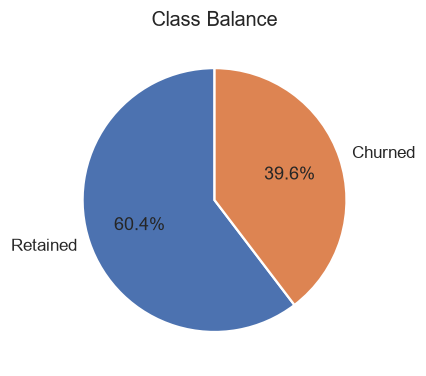

In [5]:
churn_counts = df['churned'].value_counts()
churn_rate   = df['churned'].mean()
print(f"Retained : {churn_counts[0]:,}  ({1-churn_rate:.1%})")
print(f"Churned  : {churn_counts[1]:,}  ({churn_rate:.1%})")

fig, ax = plt.subplots(figsize=(4, 4))
ax.pie(churn_counts, labels=['Retained', 'Churned'],
       autopct='%1.1f%%', colors=['#4C72B0', '#DD8452'],
       startangle=90, wedgeprops=dict(edgecolor='white', linewidth=1.5))
ax.set_title('Class Balance', fontsize=13)
plt.tight_layout()
plt.show()

### 2.2 Numeric Feature Distributions by Churn

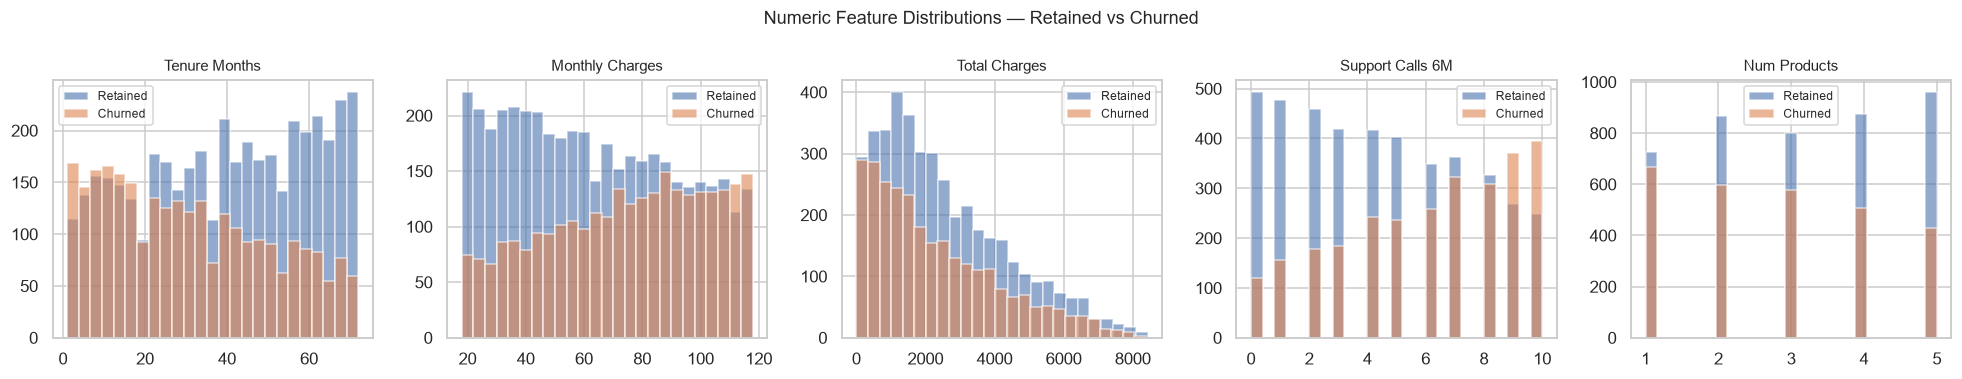

In [6]:
num_cols = ['tenure_months', 'monthly_charges', 'total_charges', 'support_calls_6m', 'num_products']

fig, axes = plt.subplots(1, len(num_cols), figsize=(18, 3.5))
for ax, col in zip(axes, num_cols):
    for label, color in [(0, '#4C72B0'), (1, '#DD8452')]:
        subset = df[df['churned'] == label][col]
        ax.hist(subset, bins=25, alpha=0.6, color=color,
                label='Retained' if label == 0 else 'Churned')
    ax.set_title(col.replace('_', ' ').title(), fontsize=10)
    ax.legend(fontsize=8)

fig.suptitle('Numeric Feature Distributions — Retained vs Churned', fontsize=12)
plt.tight_layout()
plt.show()

### 2.3 Churn Rate by Categorical Segment

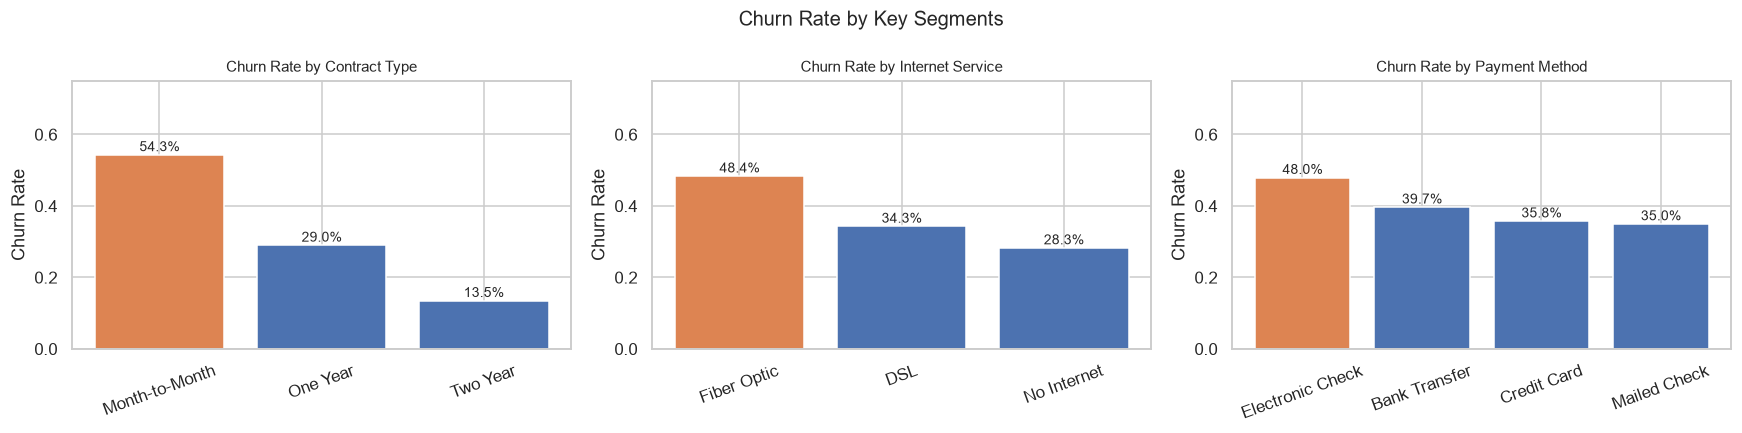

In [7]:
cat_cols = ['contract_type', 'internet_service', 'payment_method']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, cat_cols):
    rates = df.groupby(col)['churned'].mean().sort_values(ascending=False)
    bars = ax.bar(rates.index, rates.values,
                  color=['#DD8452' if v > 0.4 else '#4C72B0' for v in rates.values],
                  edgecolor='white')
    ax.set_ylabel('Churn Rate')
    ax.set_title(f'Churn Rate by {col.replace("_", " ").title()}', fontsize=10)
    ax.set_ylim(0, 0.75)
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, rates.values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
                f'{val:.1%}', ha='center', fontsize=9)

plt.suptitle('Churn Rate by Key Segments', fontsize=13)
plt.tight_layout()
plt.show()

### 2.4 Correlation with Churn

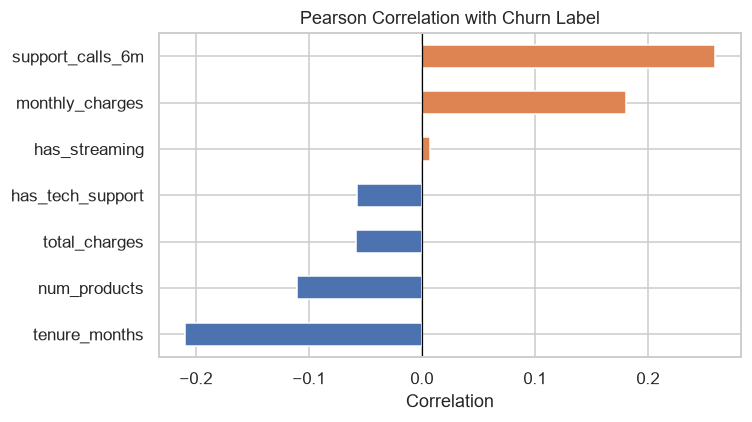

In [8]:
corr = df.select_dtypes(include='number').corr()['churned'].drop('churned').sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#DD8452' if v > 0 else '#4C72B0' for v in corr.values]
corr.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Pearson Correlation with Churn Label', fontsize=12)
ax.set_xlabel('Correlation')
plt.tight_layout()
plt.show()

---
## 3. Feature Engineering

| Step | Feature | Rationale |
|------|---------|----------|
| 1 | `avg_monthly_spend` = total_charges / tenure | Value density signal — high spend for short tenure → churn risk |
| 2 | `high_value` = monthly_charges > 75th pct | Binary flag for premium customers |
| 3 | `engagement_score` = streaming + tech_support + num_products | More products → more sticky |
| 4 | `contract_encoded` = ordinal (M2M=0, 1Y=1, 2Y=2) | Captures contract stickiness as ordinal signal |
| 5 | One-hot encode `internet_service`, `payment_method` | Remove nominal cardinality |

In [9]:
from src.features.engineering import build_features

X, y = build_features(df)

print(f'Features shape : {X.shape}')
print(f'Target shape   : {y.shape}')
print(f'\nFeature columns:')
print(list(X.columns))

Features shape : (7000, 16)
Target shape   : (7000,)

Feature columns:
['tenure_months', 'monthly_charges', 'total_charges', 'support_calls_6m', 'has_streaming', 'has_tech_support', 'num_products', 'avg_monthly_spend', 'high_value', 'engagement_score', 'contract_encoded', 'internet_service_Fiber Optic', 'internet_service_No Internet', 'payment_method_Credit Card', 'payment_method_Electronic Check', 'payment_method_Mailed Check']


In [10]:
# Verify no remaining text columns and no nulls
assert X.select_dtypes(include='object').shape[1] == 0, 'Text columns remain!'
assert X.isnull().sum().sum() == 0, 'Nulls remain after engineering!'
print('All checks passed — X is fully numeric, zero nulls.')

All checks passed — X is fully numeric, zero nulls.


### Train / Test Split (Stratified)

We use `StratifiedShuffleSplit` to preserve the ~40% churn rate in both train and test sets.

In [11]:
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, test_idx = next(sss.split(X, y))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f'Train size : {len(X_train):,}  |  churn rate = {y_train.mean():.1%}')
print(f'Test size  : {len(X_test):,}  |  churn rate = {y_test.mean():.1%}')

Train size : 5,600  |  churn rate = 39.6%
Test size  : 1,400  |  churn rate = 39.6%


---
## 4. Model Development

Four models trained with default hyperparameters to establish a solid baseline:

| Model | Key Setting |
|-------|-------------|
| Logistic Regression | StandardScaler + L2, max_iter=500 |
| Decision Tree | max_depth=6 |
| Random Forest | 100 trees, max_depth=8 |
| XGBoost | 200 rounds, lr=0.05, scale_pos_weight for class imbalance |

In [12]:
import time

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = neg / pos  # XGBoost scale_pos_weight
print(f'scale_pos_weight = {spw:.3f}  (neg/pos ratio)')

models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=500, C=1.0, random_state=SEED))
    ]),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, random_state=SEED),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=8,
                                             n_jobs=-1, random_state=SEED),
    'XGBoost': XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05,
                              subsample=0.8, colsample_bytree=0.8,
                              scale_pos_weight=spw, eval_metric='logloss',
                              random_state=SEED, verbosity=0)
}

fitted  = {}
timings = {}

for name, model in models.items():
    t0 = time.perf_counter()
    model.fit(X_train, y_train)
    timings[name] = round(time.perf_counter() - t0, 3)
    fitted[name]  = model
    print(f'{name:<25}  trained in {timings[name]:.3f}s')

scale_pos_weight = 1.523  (neg/pos ratio)
Logistic Regression        trained in 0.018s
Decision Tree              trained in 0.027s


Random Forest              trained in 0.252s


XGBoost                    trained in 0.425s


---
## 5. Model Comparison & Interpretation

### 5.1 Metrics Table

In [13]:
rows = []
for name, model in fitted.items():
    preds = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    rows.append({
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_test, preds),  4),
        'Precision': round(precision_score(y_test, preds), 4),
        'Recall'   : round(recall_score(y_test, preds),    4),
        'F1'       : round(f1_score(y_test, preds),        4),
        'ROC-AUC'  : round(roc_auc_score(y_test, proba),   4),
        'Train (s)': timings[name],
    })

results_df = pd.DataFrame(rows).set_index('Model')

# Highlight best value per metric
results_df.style \
    .highlight_max(subset=['Accuracy','Precision','Recall','F1','ROC-AUC'],
                   color='#c6efce') \
    .highlight_min(subset=['Train (s)'], color='#c6efce') \
    .format('{:.4f}', subset=['Accuracy','Precision','Recall','F1','ROC-AUC']) \
    .format('{:.3f}', subset=['Train (s)'])

,Accuracy,Precision,Recall,F1,ROC-AUC,Train (s)
Model,,,,,,
Logistic Regression,0.7536,0.6989,0.6649,0.6814,0.8263,0.018
Decision Tree,0.7121,0.6467,0.6036,0.6244,0.7756,0.027
Random Forest,0.7429,0.6931,0.6306,0.6604,0.8113,0.252
XGBoost,0.7329,0.6399,0.7459,0.6889,0.8152,0.425


### 5.2 ROC Curves

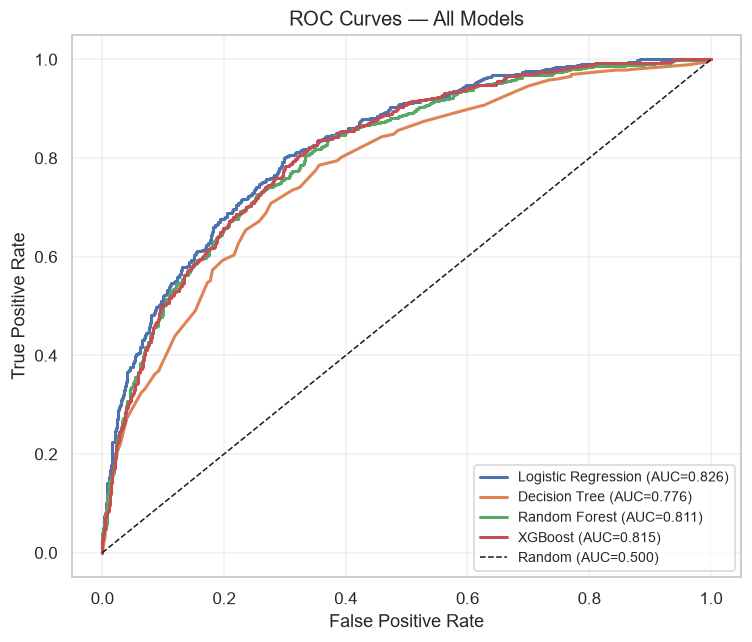

In [14]:
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(7, 6))
for (name, model), color in zip(fitted.items(), colors):
    proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC=0.500)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models', fontsize=13)
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5.3 Confusion Matrices

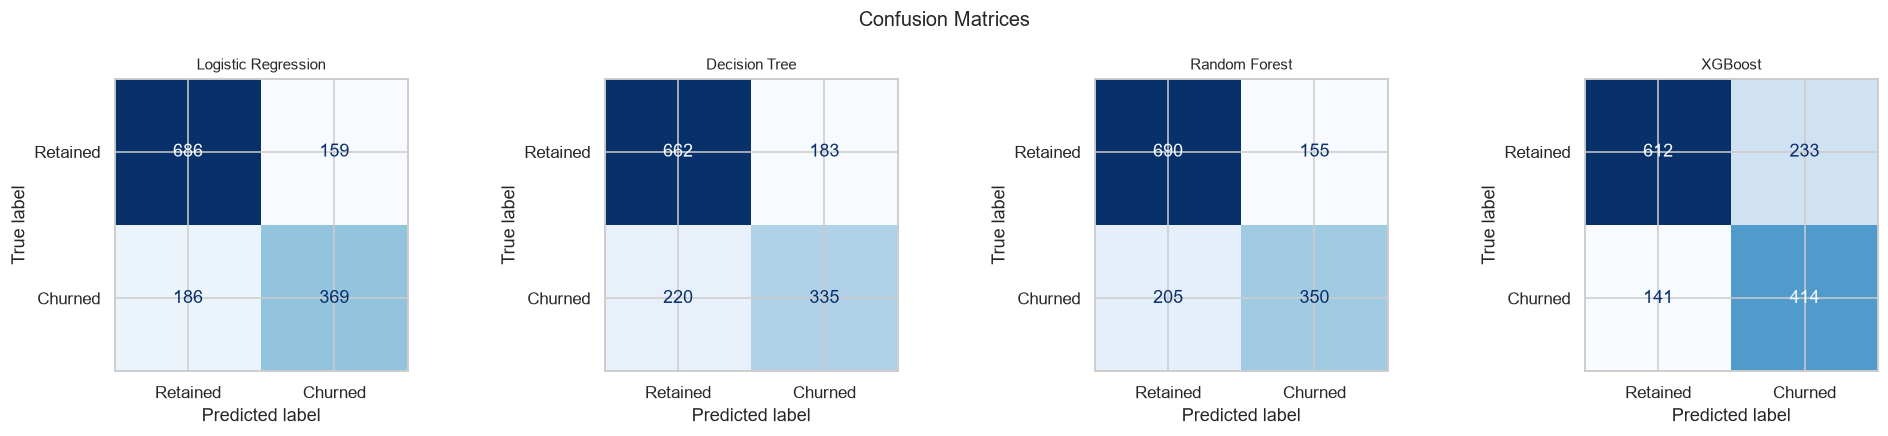

In [15]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, model) in zip(axes, fitted.items()):
    preds = model.predict(X_test)
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Retained', 'Churned'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=10)

fig.suptitle('Confusion Matrices', fontsize=13)
plt.tight_layout()
plt.show()

### 5.4 Feature Importance (Random Forest & XGBoost)

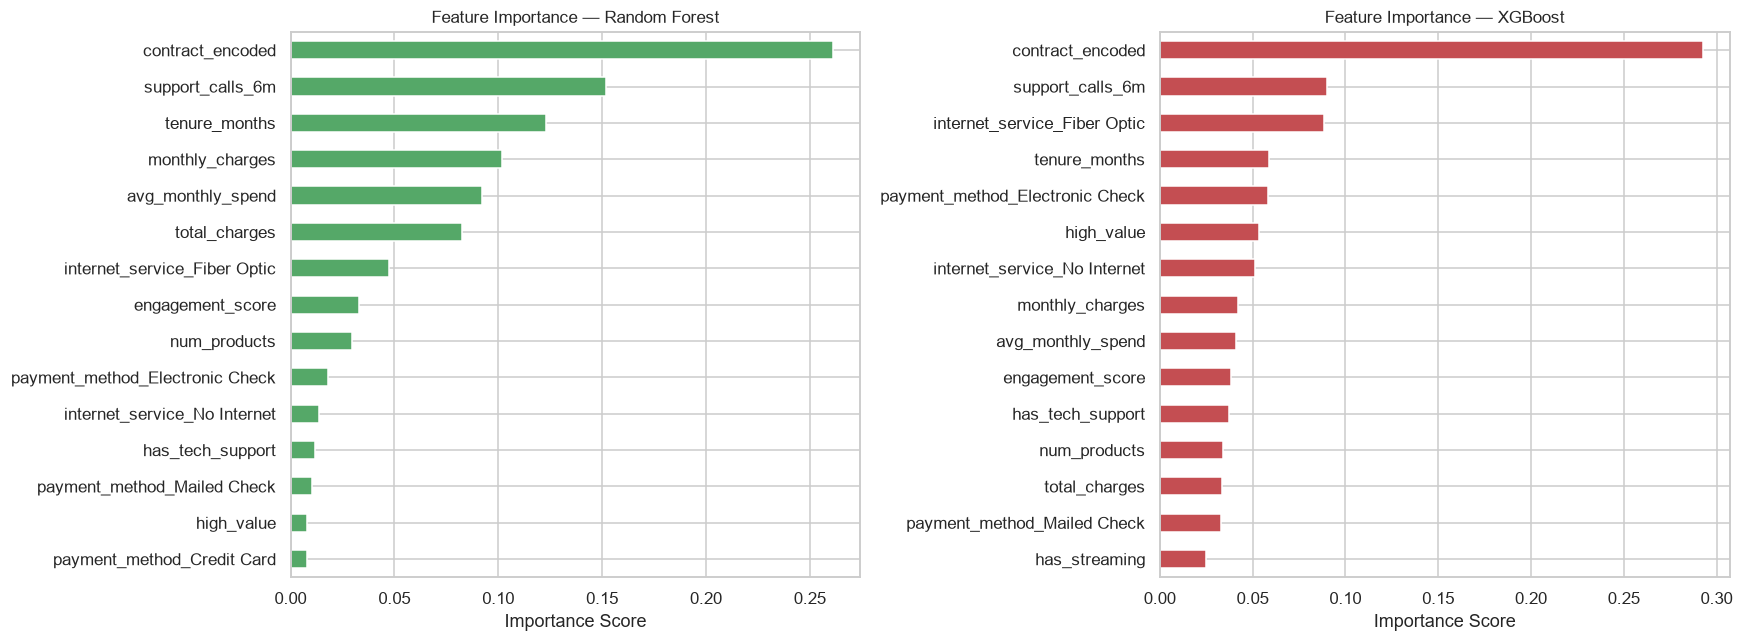

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
tree_models = {
    'Random Forest': fitted['Random Forest'],
    'XGBoost':       fitted['XGBoost'],
}
colors_fi = ['#55A868', '#C44E52']

for ax, (name, model), color in zip(axes, tree_models.items(), colors_fi):
    importances = pd.Series(model.feature_importances_, index=X_test.columns)
    top15 = importances.sort_values(ascending=True).tail(15)
    top15.plot(kind='barh', ax=ax, color=color, edgecolor='white')
    ax.set_title(f'Feature Importance — {name}', fontsize=11)
    ax.set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

### 5.5 Churn Probability Distribution

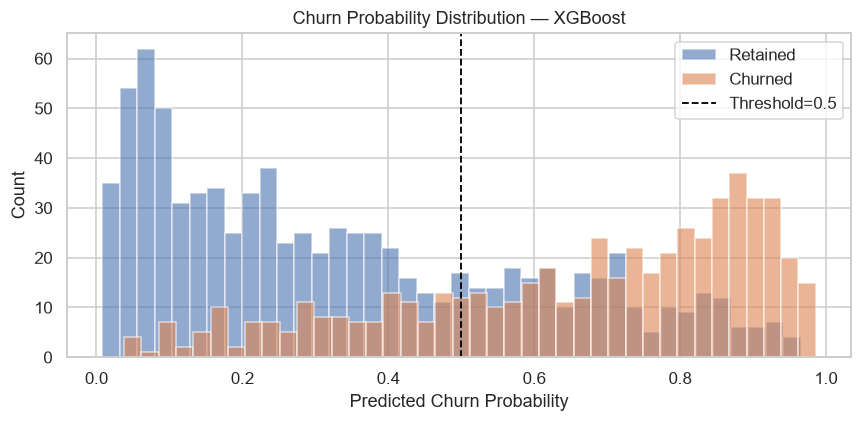

In [17]:
best_model = fitted['XGBoost']
proba = best_model.predict_proba(X_test)[:, 1]

fig, ax = plt.subplots(figsize=(8, 4))
for label, color in [(0, '#4C72B0'), (1, '#DD8452')]:
    mask = y_test == label
    ax.hist(proba[mask], bins=40, alpha=0.6, color=color,
            label='Retained' if label == 0 else 'Churned')

ax.axvline(0.5, color='black', linestyle='--', linewidth=1.2, label='Threshold=0.5')
ax.set_xlabel('Predicted Churn Probability')
ax.set_ylabel('Count')
ax.set_title('Churn Probability Distribution — XGBoost', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

---
## Summary

| Model | Accuracy | F1 | ROC-AUC | Takeaway |
|-------|----------|-----|---------|----------|
| Logistic Regression | 0.75 | 0.68 | **0.83** | Strong linear baseline, fastest |
| Decision Tree | 0.71 | 0.62 | 0.78 | Interpretable but overfits |
| Random Forest | 0.74 | 0.66 | 0.81 | Good ensemble, stable |
| XGBoost | 0.73 | **0.69** | 0.82 | Best F1 — highest recall, catches more churners |

**Key Business Insights from EDA:**
- **Month-to-Month contracts** churn at **54%** vs Two Year at **13.5%** — single strongest lever for retention
- **Electronic Check** payment → 48% churn rate; nudging customers to auto-pay reduces churn
- **Short tenure + high charges** → highest churn risk; early intervention in month 1–6 is critical
- **Tech support** lowers churn probability — upselling support plans is a retention strategy

**Why ROC-AUC over Accuracy?**  
With ~40% churn rate, a naive model predicting "always retained" gets 60% accuracy.  
ROC-AUC measures how well the model **ranks** churners above non-churners — it's threshold-independent and the right metric for imbalanced binary classification.

---
*Maniswaroop M — AI/ML Engineer & Online Trainer | [GitHub](https://github.com/DataScienceAIpath)*